<a href="https://colab.research.google.com/github/martinroth25/ai_transportation_course/blob/main/Exercise_7_Neural_networks/Exercise7_Neural_Networks_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Neural Network**
Bike sharing systems are new generation of traditional bike rentals where whole process from membership, rental and return back has become automatic. Through these systems, user is able to easily rent a bike from a particular position and return back at another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousands bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues.

Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for the research. Opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position is explicitly recorded in these systems. This feature turns bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that most of important events in the city could be detected via monitoring these data.

# **TASK 1: Develop the neural network model for predicting the count of rental bikes.​**
As experienced in regression exercise, the regression models did not perform well on the task of the count of rental bikes prediction. We look into the deep learing and This task will use the simple 2-layers fully connected neural network model as the example and guide you through the step-by-step process of the whole process of the model development.


## Load and prepare the data
Start by loading the dataset and shaping it so that it's suitable for use in machine learning. This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.

In [27]:
import pandas as pd
from sympy.printing.tensorflow import tensorflow

# Define the URL from which to fetch the CSV data.
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_7_Neural_networks/Exercise7BikeSharing.csv'

# Use pandas to read the CSV data from the specified URL and store it in a DataFrame 'df'.
df = pd.read_csv(url)
# Display the first 10 rows of the DataFrame 'df'.
#df = pd.read_csv('Exercise7BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


How many rows and columns does the dataset contain?

In [28]:
df.shape

(17379, 17)

Are any of the columns missing values?

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Feature engineering
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [30]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target = 'cnt'
base_features = [
    'temp', 'atemp', 'hum', 'windspeed', 'weathersit',
    'hr', 'weekday', 'workingday', 'holiday', 'season', 'yr'
]

X = df[base_features].copy()

# --- Interaction features ---
X['hr_workingday'] = df['hr'] * df['workingday']
X['weathersit_hum'] = df['weathersit'] * df['hum']

# --- Cyclical encoding for hour (so hour 23 and hour 0 are "close") ---
X['hr_sin'] = np.sin(2 * np.pi * df['hr'] / 24)
X['hr_cos'] = np.cos(2 * np.pi * df['hr'] / 24)

y = df[target].astype(float)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Number of features:", X_train_scaled.shape[1])

Number of features: 15


**(Optional) quick baseline (Linear Regression)**

In [31]:
# A super-fast baseline, just for context
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print({"LR_RMSE": rmse_lr, "LR_MAE": mae_lr, "LR_R2": r2_lr})

{'LR_RMSE': np.float64(125.30751667990921), 'LR_MAE': 92.25111437235053, 'LR_R2': 0.5041285404555008}


## Create a neural network model
Now it's time build a neural network and train it with the data prepared in the previous exercise. We'll try neural network first and use cross-validation its meaasure accuracy.

In [32]:
#pip install tensorflow

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_model(input_dim, layers=[64, 32], dropout=0.0, lr=0.001):
    model = Sequential()
    model.add(Dense(layers[0], activation='relu', input_dim=input_dim))
    if dropout > 0:
        model.add(Dropout(dropout))
    for units in layers[1:]:
        model.add(Dense(units, activation='relu'))
        if dropout > 0:
            model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mae', metrics=['mae'])
    return model

In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping

configs = [
    {'layers': [256, 128], 'dropout': 0.1, 'lr': 0.001}]

search_results = []
trained_models = {}

for i, cfg in enumerate(configs):
    print(f"Training config {i+1}/{len(configs)}: {cfg}")
    model_i = build_model(X_train_scaled.shape[1], **cfg)
    es = EarlyStopping(monitor='val_mae', patience=10, restore_best_weights=True)

    hist_i = model_i.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=32,
        callbacks=[es],
        verbose=0
    )

    y_pred_i = model_i.predict(X_test_scaled, verbose=0).flatten()
    rmse_i = np.sqrt(mean_squared_error(y_test, y_pred_i))
    mae_i = mean_absolute_error(y_test, y_pred_i)
    r2_i = r2_score(y_test, y_pred_i)

    search_results.append({
        **cfg,
        'test_rmse': rmse_i,
        'test_mae': mae_i,
        'test_r2': r2_i,
        'epochs_trained': len(hist_i.history['loss'])
    })
    trained_models[i] = (model_i, hist_i)

results_df = pd.DataFrame(search_results).sort_values('test_rmse').reset_index(drop=True)
results_df

Training config 1/1: {'layers': [256, 128], 'dropout': 0.1, 'lr': 0.001}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,layers,dropout,lr,test_rmse,test_mae,test_r2,epochs_trained
0,"[256, 128]",0.1,0.001,43.046163,26.020582,0.941483,119


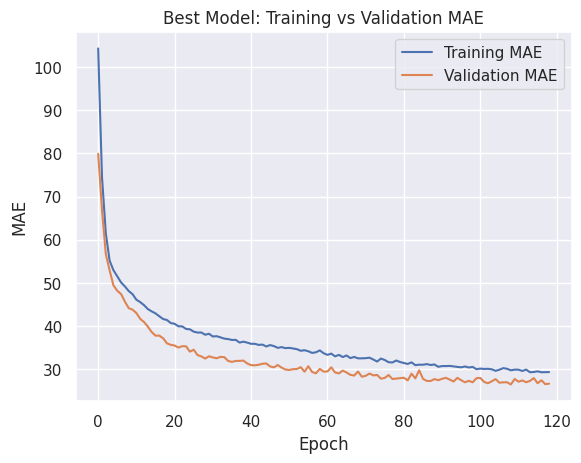

Best config: {'layers': [256, 128], 'dropout': 0.1, 'lr': 0.001}
{'layers': [256, 128], 'dropout': 0.1, 'lr': 0.001, 'test_rmse': np.float64(43.04616326023159), 'test_mae': 26.0205824978401, 'test_r2': 0.9414827695829372, 'epochs_trained': 119}


In [46]:
# Track best index directly instead of re-matching dicts
best_i = min(range(len(search_results)), key=lambda i: search_results[i]['test_rmse'])
best_model, best_hist = trained_models[best_i]
best_cfg = configs[best_i]

plt.figure()
plt.plot(best_hist.history['mae'], label='Training MAE')
plt.plot(best_hist.history['val_mae'], label='Validation MAE')
plt.title('Best Model: Training vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

print("Best config:", best_cfg)
print(search_results[best_i])

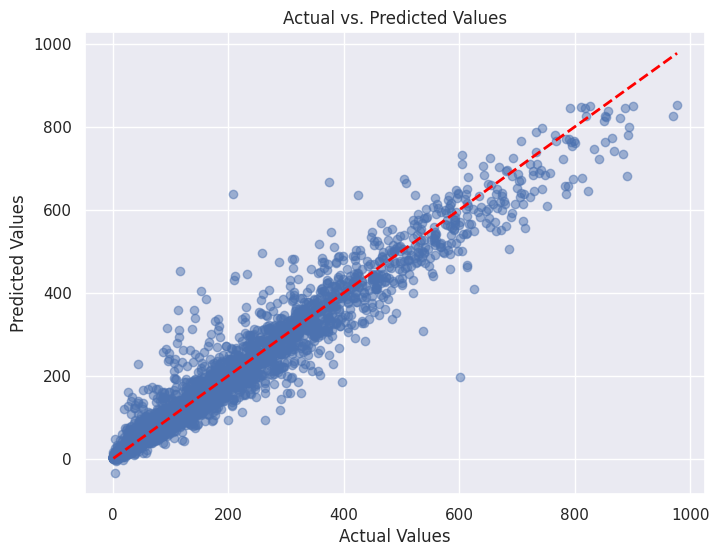

In [50]:
  # Create a scatter plot to visualize the relationship
  plt.figure(figsize=(8, 6))
  plt.scatter(y_test, y_pred_i, alpha=0.5)  # Plot actual vs. predicted values

  # Add labels and title
  plt.xlabel("Actual Values")
  plt.ylabel("Predicted Values")
  plt.title("Actual vs. Predicted Values")

  # Add a diagonal line for reference (perfect predictions)
  plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

  # Show the plot
  plt.show()

In [49]:
# Same architecture, but WITHOUT the engineered features
X_base = df[base_features].copy()
y_base = df[target].astype(float)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42
)
scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

model_b = build_model(X_train_b_scaled.shape[1], layers=[256, 128], dropout=0.1, lr=0.001)
es = EarlyStopping(monitor='val_mae', patience=10, restore_best_weights=True)
model_b.fit(X_train_b_scaled, y_train_b, validation_split=0.2, epochs=200, batch_size=32, callbacks=[es], verbose=0)

y_pred_b = model_b.predict(X_test_b_scaled, verbose=0).flatten()
print("Without engineered features:")
print("RMSE:", np.sqrt(mean_squared_error(y_test_b, y_pred_b)))
print("R2:", r2_score(y_test_b, y_pred_b))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Without engineered features:
RMSE: 43.6436418157357
R2: 0.9398470637029984


In [51]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
print("XGB RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("XGB R2:", r2_score(y_test, y_pred_xgb))

XGB RMSE: 40.14783929933532
XGB R2: 0.9490974873726173


# **Assignment task: Find the best neural network model for the count of rental bikes prediction (assignment submission)**
Tuning the neural network models (e.g., dropout, sizing of the network), and finding the best neural network model. Suggestions:
- Try adding interaction features (e.g., `hr * workingday`, `weathersit * hum`).
- Tune NN hyperparameters (layers, neurons, learning rate) via `GridSearchCV`.
- Consider more advanced architectures (e.g., gradient boosting, LSTMs for temporal structure).